In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv('heart.csv')

In [8]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## **EDA**

In [11]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [12]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [14]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

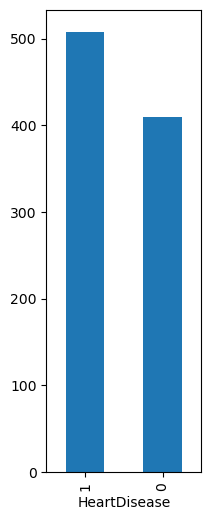

In [24]:
df['HeartDisease'].value_counts().plot(kind="bar",figsize=(2,6))

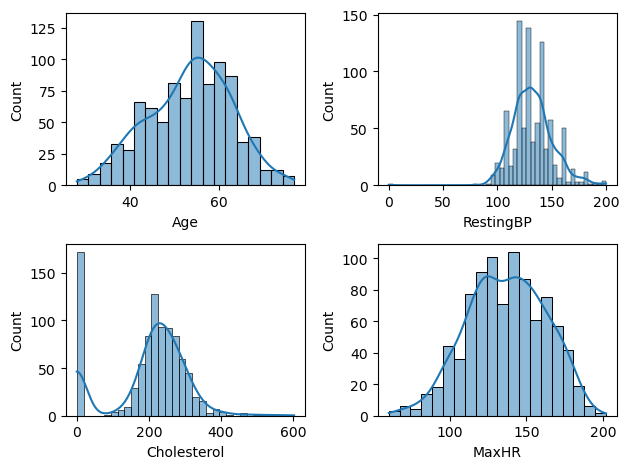

In [33]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)


plt.tight_layout() #stops the plotting to overlap

In [27]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
185      1
98       1
92       1
113      1
164      1
Name: count, Length: 67, dtype: int64

In [34]:
df['Cholesterol'].value_counts() 
#there is no way a person can have a cholestrol as '0' it is a wrong data
#we have to correct it

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [36]:
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [37]:
ch_mean

np.float64(244.6353887399464)

In [46]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol']=df['Cholesterol'].round(0)

In [45]:
df['Cholesterol'].value_counts() 

Cholesterol
245.0    178
254.0     11
223.0     10
220.0     10
216.0      9
        ... 
347.0      1
365.0      1
412.0      1
491.0      1
131.0      1
Name: count, Length: 221, dtype: int64

In [80]:
bp_mean=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['RestingBP']=df['RestingBP'].replace(0,bp_mean)
df['RestingBP']=df['RestingBP'].round(2)
df.drop('RestingBPl', axis=1, inplace=True)

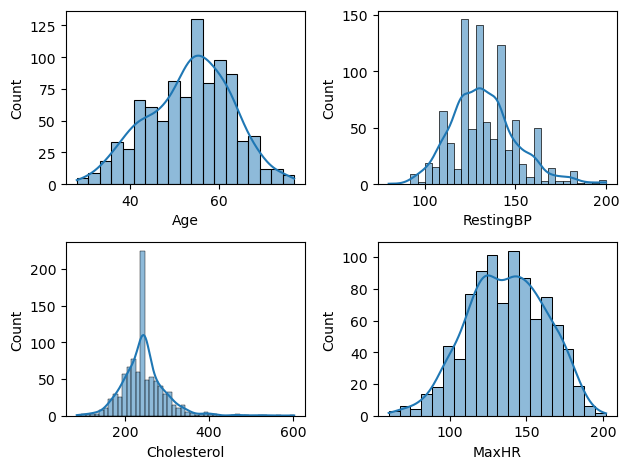

In [64]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)


plt.tight_layout() #stops the plotting to overlap

<Axes: xlabel='Sex', ylabel='count'>

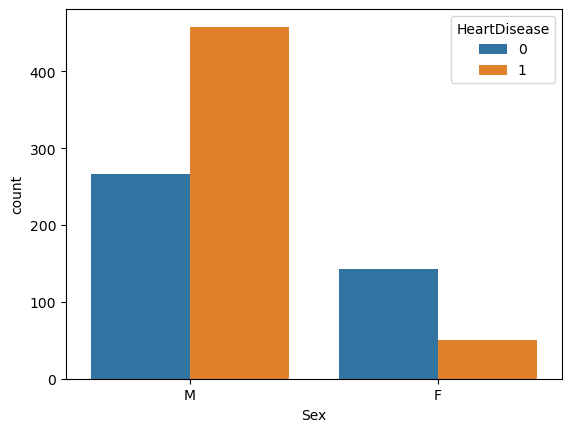

In [65]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

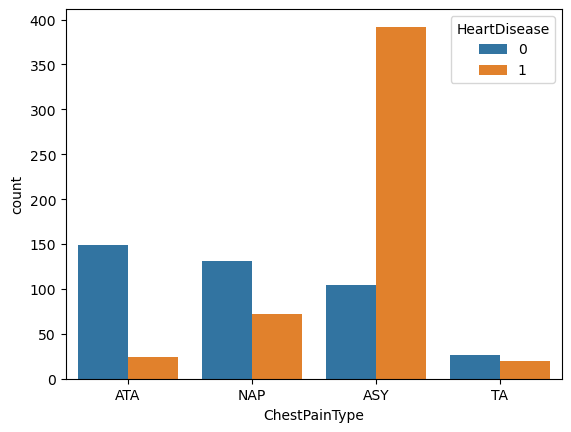

In [66]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

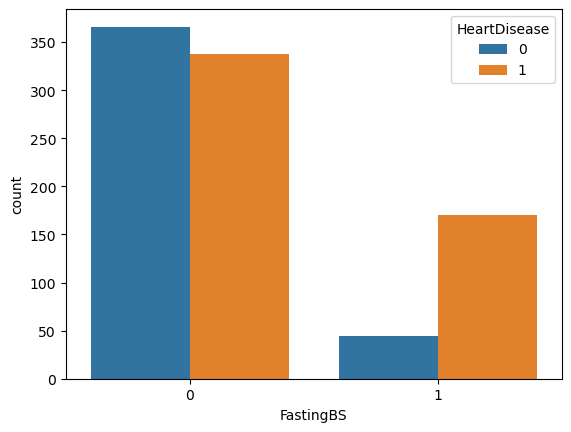

In [67]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

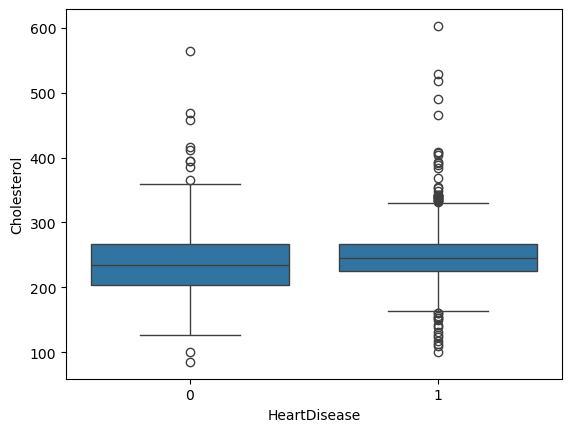

In [68]:
sns.boxplot(x='HeartDisease',y='Cholesterol',data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

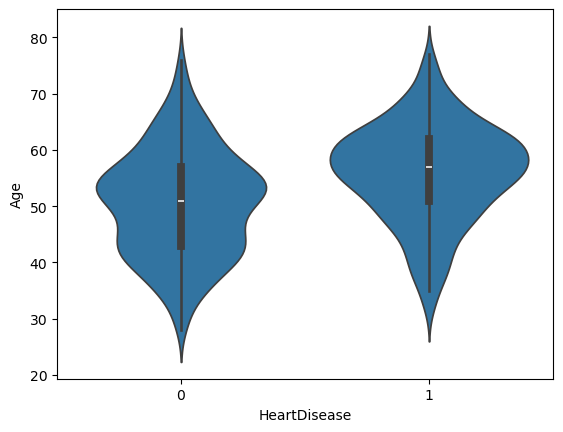

In [69]:
sns.violinplot(x='HeartDisease', y='Age', data=df)

<Axes: >

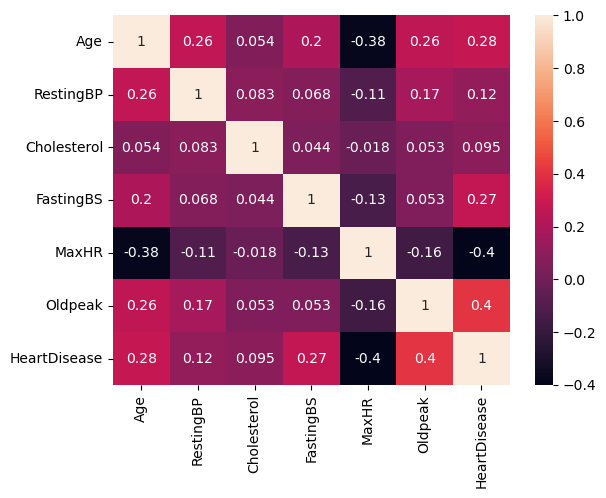

In [81]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [82]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


# data preprocessing and cleaning

In [94]:
df_encode =pd.get_dummies(df)
df_encode=df_encode.astype(int)

In [95]:
df_encode.drop('ExerciseAngina_N', axis=1, inplace=True)

In [96]:
df_encode.drop('Sex_M', axis=1, inplace=True)

In [97]:
from sklearn.preprocessing import StandardScaler
num_cols=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler= StandardScaler()

df_encode[num_cols] =scaler.fit_transform(df_encode[num_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.831244,0,1.382928,-0.727592,0,0,0,1,0,0,0,1,0,0,0,0,1
1,-0.478484,1.527224,-1.214200,0,0.754157,0.282891,1,1,0,0,1,0,0,1,0,0,0,1,0
2,-1.751359,-0.141284,0.718651,0,-1.525138,-0.727592,0,0,0,1,0,0,0,0,1,0,0,0,1
3,-0.584556,0.303651,-0.576172,0,-1.132156,0.282891,1,1,1,0,0,0,0,1,0,1,0,1,0
4,0.051881,0.971054,-0.932717,0,-0.581981,-0.727592,0,0,0,0,1,0,0,1,0,0,0,0,1
